In [5]:
import numpy as np
import xarray as xr
import pandas as pd
import sys, os
from glob import glob 
# Gross fix this
sys.path.append(os.path.dirname(os.getcwd())); from utils import *

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import torch

def normalize(video, scale=255):
    video_tensor = torch.from_numpy(video).float()
    vmin, vmax = video_tensor.min(), video_tensor.max()
    normalized = scale * (video_tensor - vmin) / (vmax - vmin)
    return normalized.byte().numpy()

In [7]:
# Here's a list of the video keys and associated missions
files_and_missions = [('20211013T130100Z', []),
                      ('20211012T133100Z', ['28']),
                      ('20211010T160100Z', []),
                      ('20211014T120100Z', []),
                      ('20211014T123100Z', ['33']),
                      ('20211010T150100Z', []),
                      ('20211013T170100Z', []),
                      ('20211011T140100Z', []),
                      ('20211011T143100Z', ['25']),
                      ('20211014T130100Z', ['34']),
                      ('20211013T160100Z', []),
                      ('20211013T163100Z', ['31']),
                      ('20211013T140100Z', []),
                      ('20211013T143100Z', ['30']),
                      ('20211011T130100Z', [])]

good_data_only = [
    ('20211014T120100Z', 'north half good'),
    ('20211014T123100Z', 'north half good. lighting exposure changes'),
    ('20211013T170100Z', 'some lighting'), 
    ('20211014T130100Z', 'north only, some low contrast')
    ('20211028T153100Z')
]

good_data_part_two = [
    '20211026T160100Z',
    '20211028T140100Z',
    '20211027T160100Z',
    '20211027T163100Z'
]


array_8m = xr.load_dataset('../../../data/FRF-ocean_waves_8m-array_202110.nc')


In [56]:
# Go through and find all the > SECONDS duration clips
data = []
SECONDS = 60
for time, missions in files_and_missions:
    file = os.path.join('../../../data/argus', f'ArgusFF_{time}_RectifiedVideo.avi')
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file, dtype=np.uint8)
    
    bad_data = np.sum(timestack == 0, axis=2).sum(axis=1)
    good_data = bad_data == bad_data.min()
    edges = np.convolve((np.convolve(good_data, np.ones(FPS * SECONDS + 1)) == FPS * SECONDS + 1),np.array([1, -1]))

    start = np.where(edges == 1)[0]
    end =   np.where(edges == -1)[0]

    data.append(
        {
            'video': {
                'filename': os.path.abspath(file),
                'key': time,
                'good_data': list(zip(start, end)) 
            },
            'missions': [{
                'filename': os.path.abspath(f'../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission{mission}.nc')
            } for mission in missions]
        }
    )
    del timestack
    print(data[-1], (end-start)/FPS/60, 'min')

3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:06<00:00, 602.32it/s]


{'video': {'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/argus/ArgusFF_20211013T130100Z_RectifiedVideo.avi', 'key': '20211013T130100Z', 'good_data': [(120, 211), (2263, 2795)]}, 'missions': []} [0.75833333 4.43333333] min
3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:10<00:00, 373.31it/s]


{'video': {'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/argus/ArgusFF_20211012T133100Z_RectifiedVideo.avi', 'key': '20211012T133100Z', 'good_data': [(120, 213), (1185, 2702)]}, 'missions': [{'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission28.nc'}]} [ 0.775      12.64166667] min
3.072gb allocated


...

{'video': {'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/argus/ArgusFF_20211013T140100Z_RectifiedVideo.avi', 'key': '20211013T140100Z', 'good_data': [(120, 196), (1419, 2885)]}, 'missions': []} [ 0.63333333 12.21666667] min
3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:05<00:00, 661.33it/s]


{'video': {'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/argus/ArgusFF_20211013T143100Z_RectifiedVideo.avi', 'key': '20211013T143100Z', 'good_data': [(120, 169), (2048, 2946)]}, 'missions': [{'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission30.nc'}]} [0.40833333 7.48333333] min
3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:06<00:00, 618.51it/s]


{'video': {'filename': '/Users/mleclair/Dropbox/phd/code/dunex/data/argus/ArgusFF_20211011T130100Z_RectifiedVideo.avi', 'key': '20211011T130100Z', 'good_data': [(120, 205), (581, 592), (2394, 2872)]}, 'missions': []} [0.70833333 0.09166667 3.98333333] min


In [11]:
def normalize(video, scale=255):
    video_tensor = torch.from_numpy(video).float()
    vmin, vmax = video_tensor.min(), video_tensor.max()
    normalized = scale * (video_tensor - vmin) / (vmax - vmin)
    return normalized.byte().numpy()

In [48]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

def lowpass_filter_timestack(timestack, cutoff_freq, fs, order=5):
    """
    Apply a low-pass filter to video frames in a timestack.
    
    Parameters:
    timestack (numpy.ndarray): 3D array of shape (t, y, x) representing the timestack
    cutoff_freq (float): Cutoff frequency of the low-pass filter in Hz
    fs (float): Sampling frequency of the video in Hz
    order (int): Order of the Butterworth filter (default: 5)
    
    Returns:
    numpy.ndarray: Filtered timestack with the same shape as the input
    """
    t, y, x = timestack.shape
    
    # Design the Butterworth low-pass filter
    nyquist_freq = 0.5 * fs
    normalized_cutoff = cutoff_freq / nyquist_freq
    b, a = signal.butter(order, normalized_cutoff, btype='low', analog=False)
    
    # Apply the filter along the time axis for each pixel
    filtered_timestack = np.zeros_like(timestack)
    for i in tqdm(range(y)):
        for j in range(x):
            filtered_timestack[:, i, j] = signal.filtfilt(b, a, timestack[:, i, j].astype(float))
    
    return filtered_timestack

In [57]:
for dat in data:
    vid = dat['video']
    file = vid['filename']
    slices = vid['good_data']
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file)
    print(vid['key'])
    xrd = []
    for start, end in slices:
        # breakers = np.zeros_like(timestack[start:end])
        
        # Tp = array_8m.sel(time=pd.to_datetime(vid['key']).tz_localize(None), method='nearest').waveTp.item()
        # sec = np.linspace(0, len(breakers)/FPS, len(breakers))
        # Tps = sec / Tp

        # # First in timestack   
        # for i in tqdm(range(1, 1600)):
        #     stack = timestack[start:end, i]# - timestack[start:end, i-1] 
        #     breakers[:, i, :] = remove_loose_pixels_not_in_line(
        #                             detect_leading_edges(stack >= np.percentile(stack, 95, axis=1)[:, np.newaxis], 0),
        #                         min_line_length=3, eps=3, min_samples=7)

        # # Then in image
        # for i in tqdm(range(len(breakers))):
        #     breakers[i] = remove_loose_pixels_not_in_line(
        #                             detect_leading_edges(breakers[i], 1),
        #                         min_line_length=3, eps=3, min_samples=5)


        # breaker_labels = filter_and_label_spatiotemporal_propagation(breakers, min_size=6, time_window=4, space_window=6)
        WRITE_FPS = FPS * 3

        # accumulated_qb = np.nan_to_num(np.cumsum(breakers, axis=0) / Tps[:, np.newaxis, np.newaxis])
        # accumulated_qb_video_seq = (np.minimum(1, accumulated_qb/2.5)*255).astype(np.uint8)
        # write_sequence_to_mp4(accumulated_qb_video_seq, f'{vid['key']}_accumulated_qb_{start}.mp4', FPS=WRITE_FPS)
        # write_sequence_to_mp4((breakers*255).astype(np.uint8) , f'{vid['key']}_breakers_{start}.mp4', FPS=WRITE_FPS)
        
        # def show_breakers(frame, i, breakers):
        #     if np.any(breakers[i] != 0):
        #         frame[ndi.binary_dilation(breakers[i]!=0, iterations=2)] = np.array(([0, 0, 255]))
        #     return frame
        
        # write_sequence_to_mp4((timestack[start:end]).astype(np.uint8) , f'{vid['key']}_breakers_highlight_{start}.mp4', fn=show_breakers, FPS=WRITE_FPS, data=breakers)
        Tp = array_8m.sel(time=pd.to_datetime(vid['key']).tz_localize(None), method='nearest').waveTp.item()
        diff = timestack[start+2:end] - (0.5 * (timestack[start:end-2] + timestack[start+1:end-1]))
        normalized = normalize(diff)
        write_sequence_to_mp4(normalized, f'diff/{vid['key']}_diff_{start}.mp4', FPS=WRITE_FPS)
        write_sequence_to_mp4(timestack[start+2:end], f'diff/{vid['key']}_{start}.mp4', FPS=WRITE_FPS)

        # ds = argus_sequence_to_xarray(breakers, 'breaker' fs=2, start=pd.to_datetime(vid['key']) + pd.Timedelta(seconds=start/FPS))
        # ds.time.attrs.pop('units', None)
        # xrd.append(ds)
    
    # xr.combine_by_coords(xrd).to_netcdf(f'{vid['key']}.nc')
    del xrd
    del timestack
    # del breakers

6.144gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:05<00:00, 670.99it/s]


20211013T130100Z


100%|██████████| 530/530 [00:03<00:00, 162.79it/s]


...

Building Timestack: 100%|██████████| 3840/3840 [00:06<00:00, 630.71it/s]


20211010T150100Z


 19%|█▉        | 229/1215 [00:01<00:07, 126.70it/s]


KeyboardInterrupt: 

: 

20211013T140100Z.nc
20211014T123100Z.nc
20211013T160100Z.nc
20211013T170100Z.nc
20211011T140100Z.nc
20211013T143100Z.nc
20211013T130100Z.nc
20211012T133100Z.nc
20211010T160100Z.nc
20211014T130100Z.nc
20211011T143100Z.nc
20211010T150100Z.nc
20211014T120100Z.nc
20211011T130100Z.nc
20211013T163100Z.nc


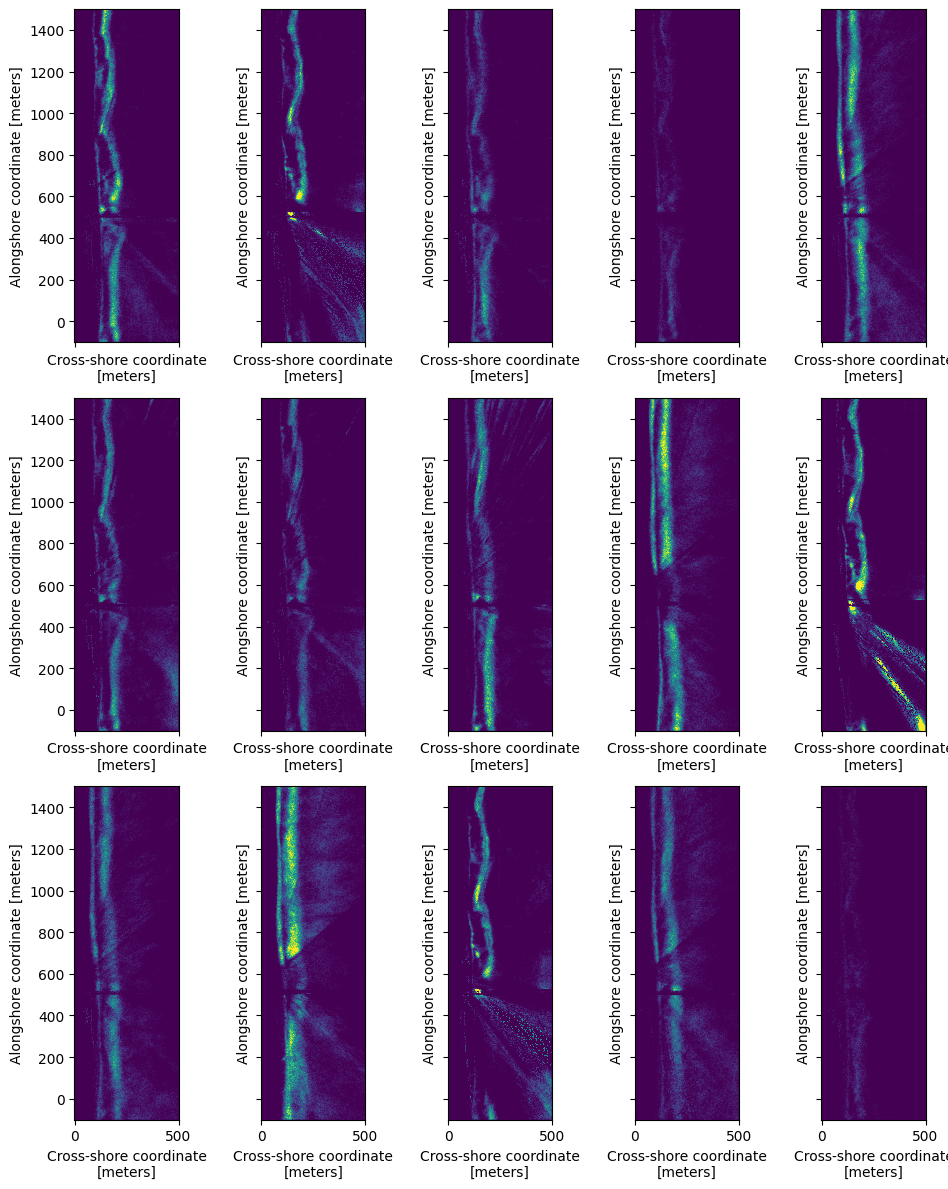

In [50]:
files = glob('*.nc')


fig, axs = plt.subplots(3, len(files)//3, figsize=(10, 12), sharex=True, sharey=True)

def flatten(xss):
    return [x for xs in xss for x in xs]


flat_list = flatten(axs)

for i, file in enumerate(files):
    print(file)
    ds = xr.load_dataset(file)
    # ds['breaker'] = ds['__xarray_dataarray_variable__'] 
    # ds = ds.drop_vars('__xarray_dataarray_variable__')
    # ds.to_netcdf(file)
    seconds = (ds.time.max() - ds.time.min()).dt.seconds.item()
    (ds.breaker.sum('time')/seconds).plot(ax=flat_list[i], vmin=0, vmax=.05, add_colorbar=False)
    flat_list[i].set_aspect(1)
plt.tight_layout()
plt.show()

3.072gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:04<00:00, 952.82it/s] 


3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:04<00:00, 860.69it/s] 


...

Building Timestack: 100%|██████████| 3840/3840 [00:05<00:00, 642.87it/s]


3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:06<00:00, 638.92it/s]


3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:06<00:00, 635.70it/s]


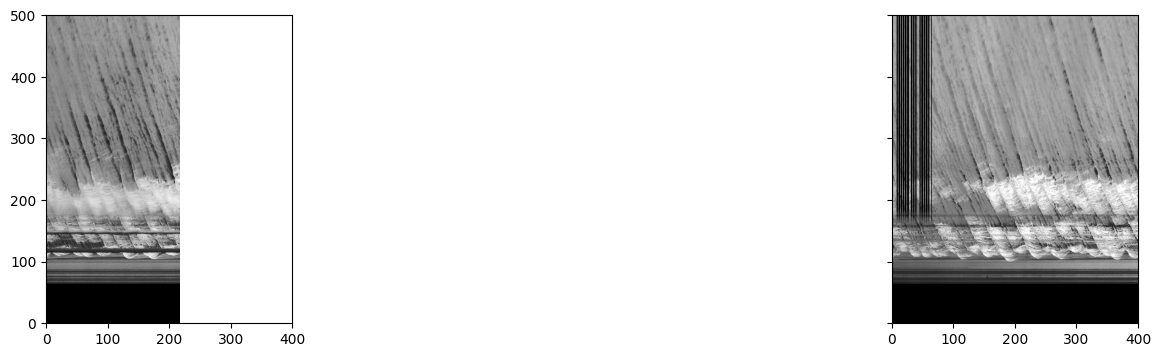

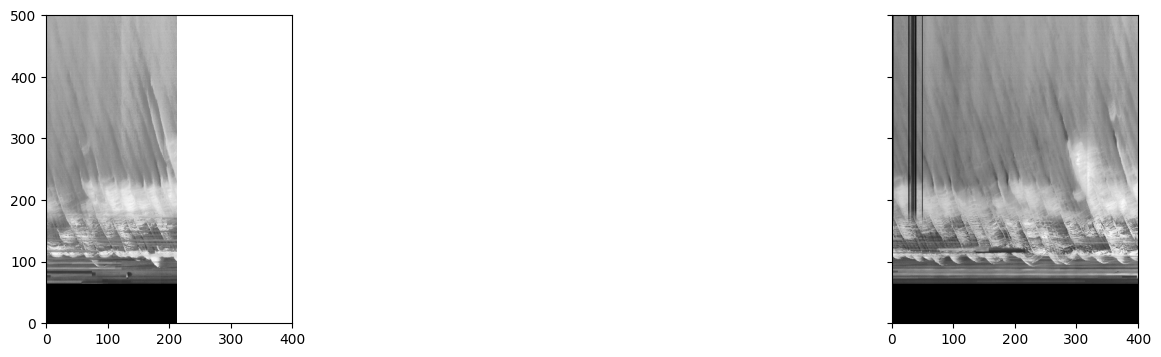

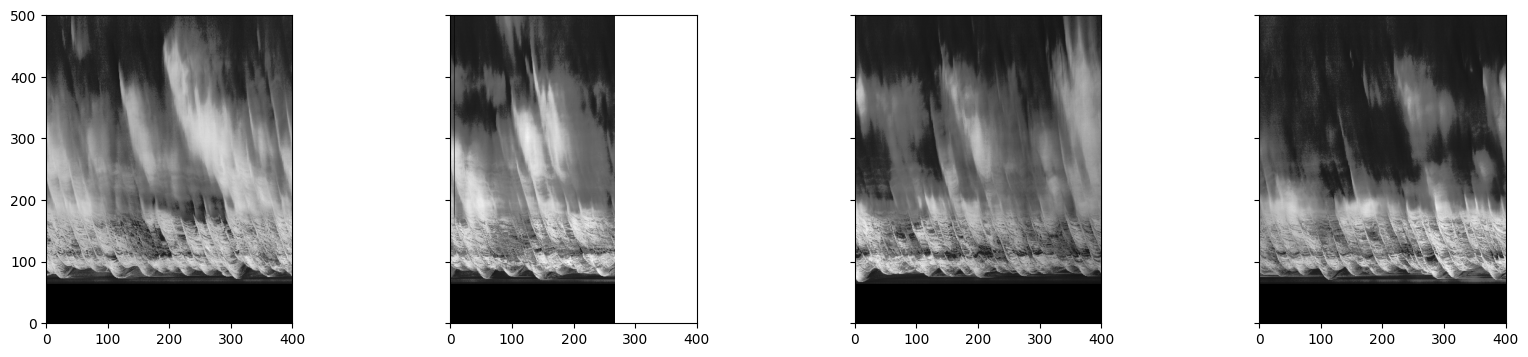

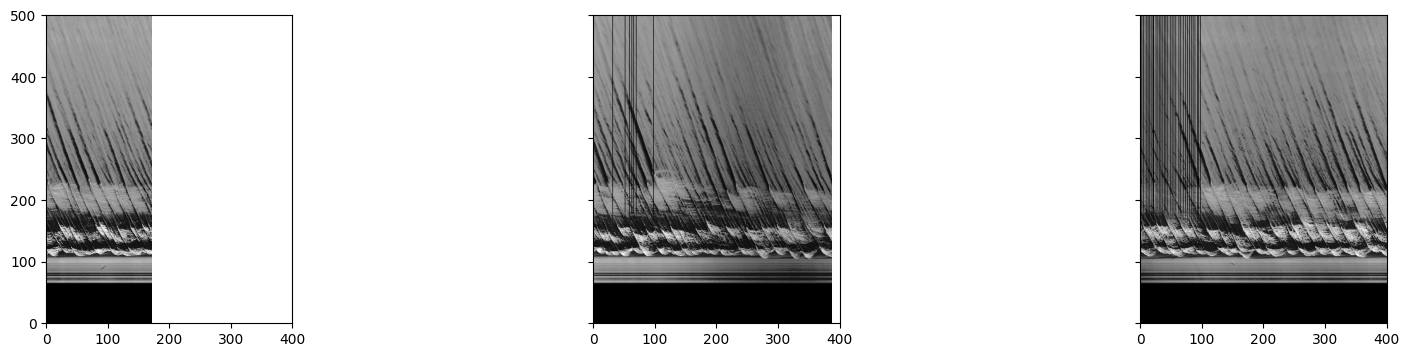

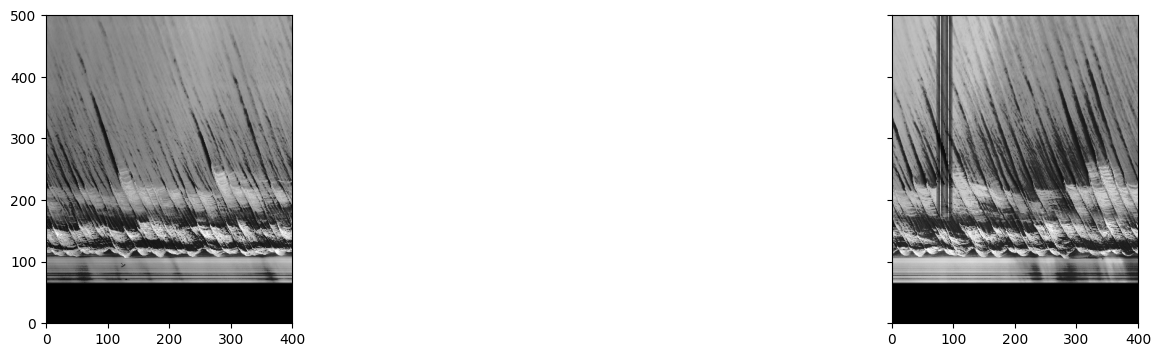

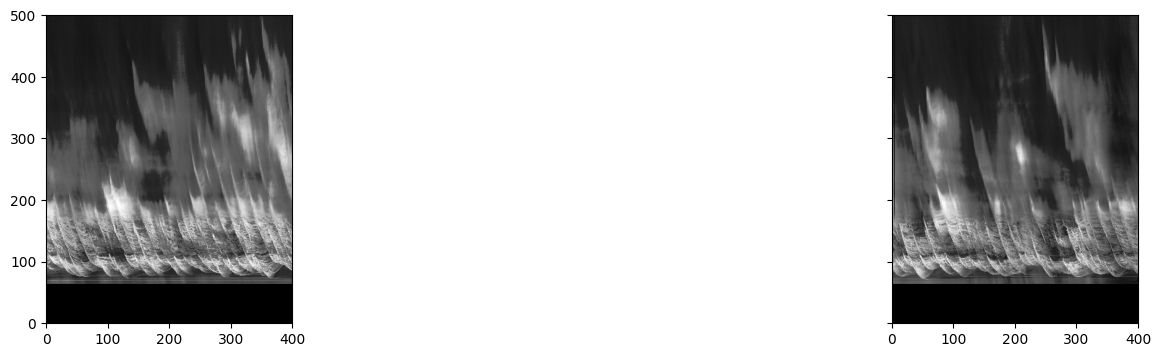

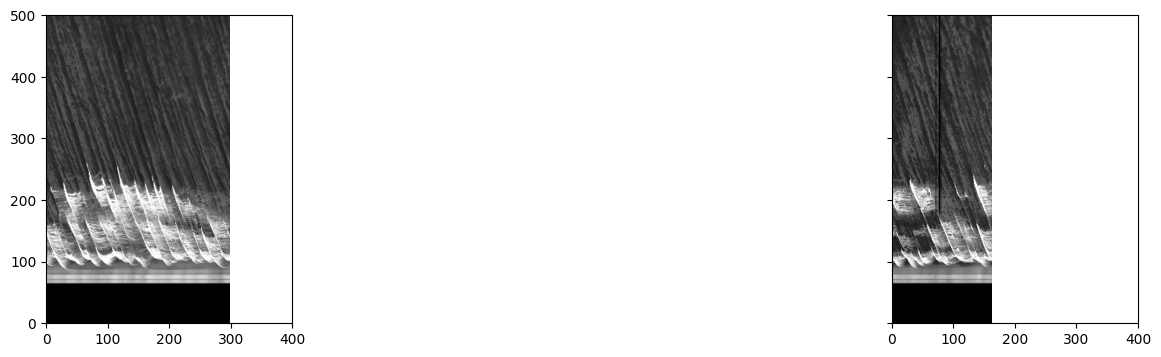

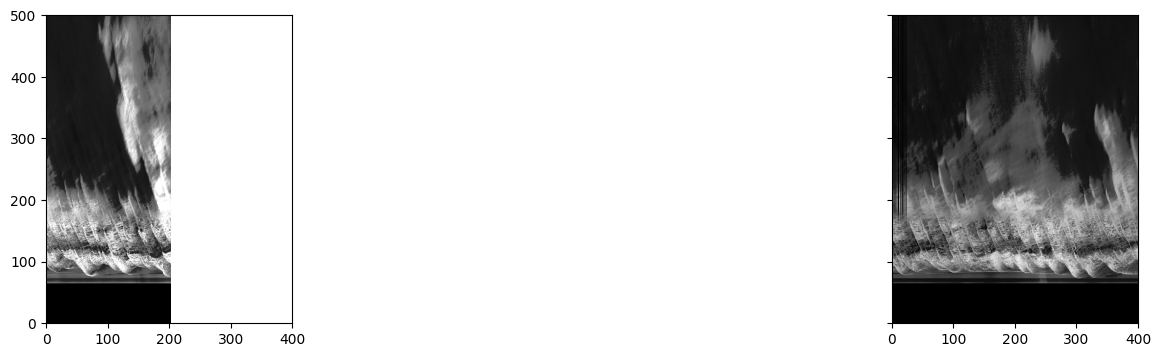

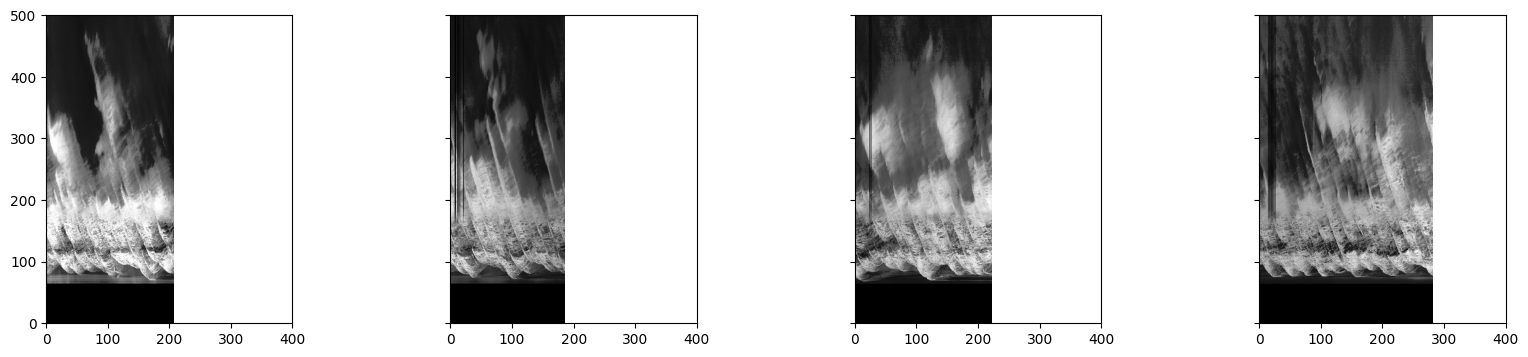

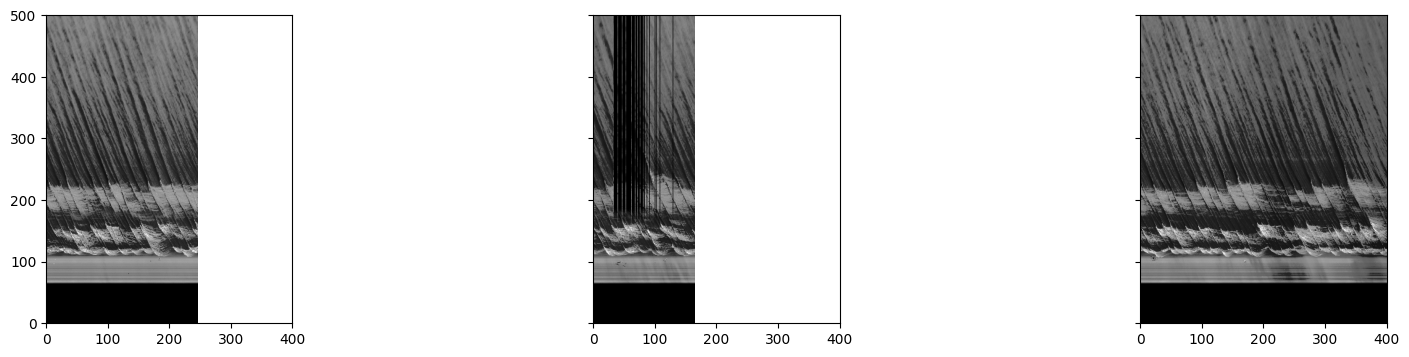

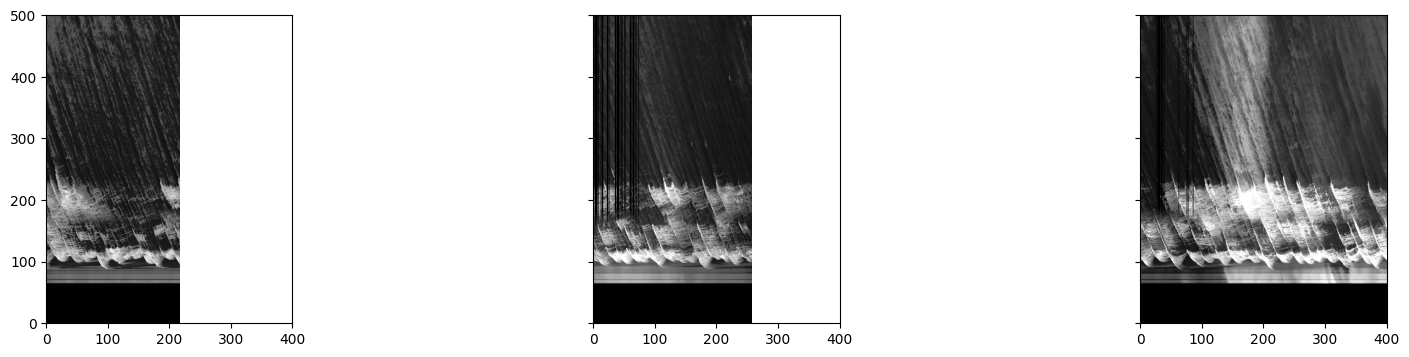

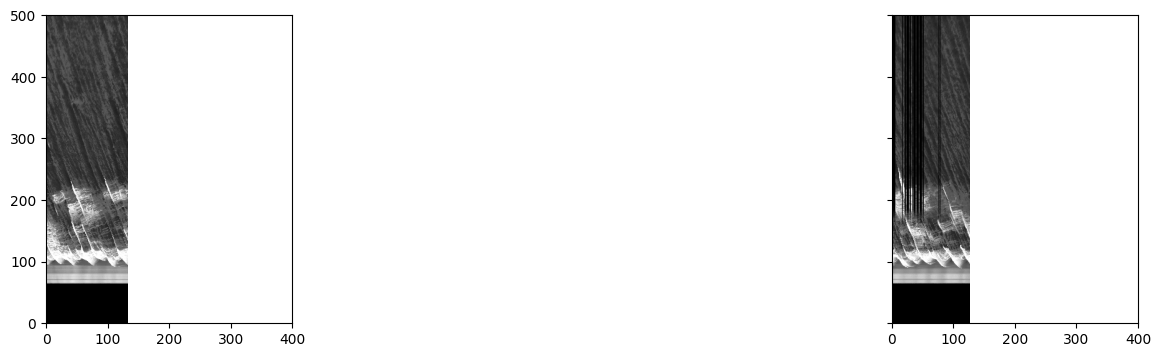

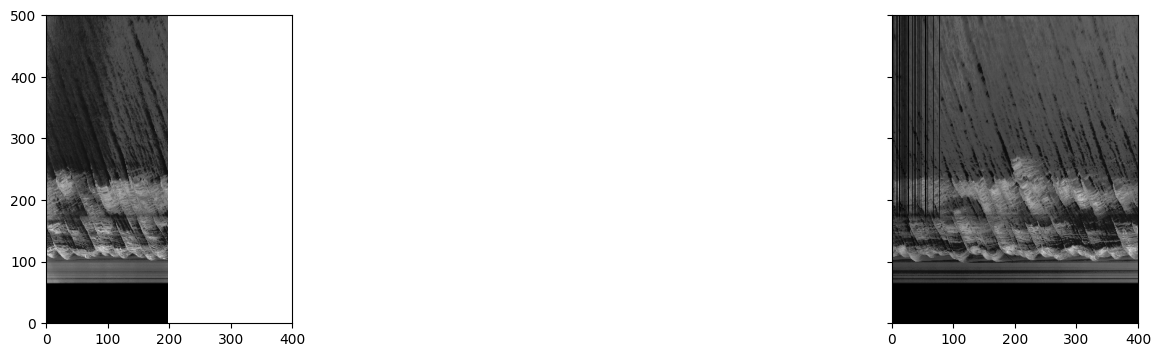

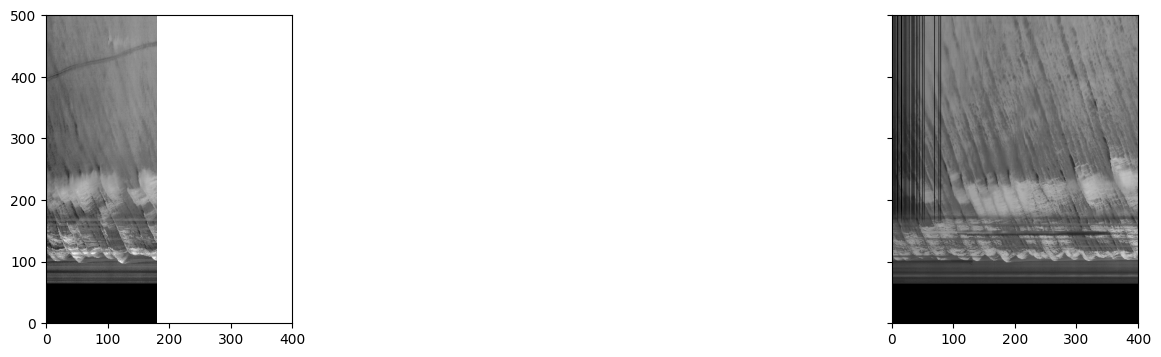

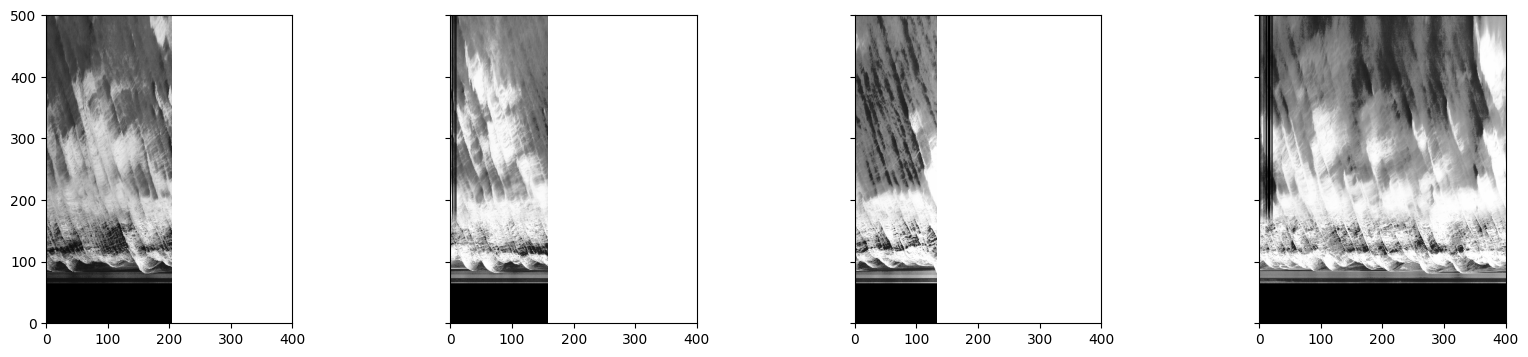

In [66]:
Y = 800
for dat in data:
    vid = dat['video']
    file = vid['filename']
    slices = vid['good_data']
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file)

    xrd = []
    fig, axs = plt.subplots(1, len(slices), sharey=True, sharex=True, figsize=(20, 4))
    for i, (start, end) in enumerate(slices):
        axs[i].imshow(timestack[start:end, Y, :].T)
        axs[i].set_xlim(0, 400)
        axs[i].set_ylim(0, 500)

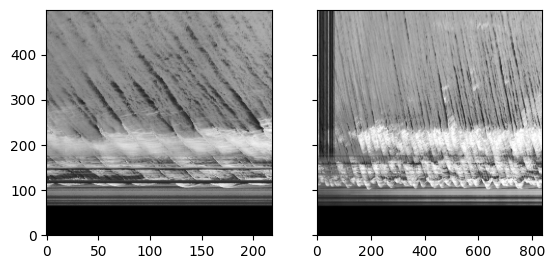

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [63]:
fig, axs = plt.subplots(1, len(slices), sharey=True)
for i, (start, end) in enumerate(slices):
    plt.figure()
    axs[i].imshow(timestack[start:end, Y, :].T)
    axs[i].set_aspect((end-start)/500)
